# People Intelligence Case: Analysis Walkthrough
**Mike Spencer · Associate, People Intelligence · all answers as of September 1, 2026**

This notebook is the audit trail behind the write-up and the HRBP dashboard. It does three things:

1. **Shows every data-quality issue**: the evidence, why it matters, and the fix applied.
2. **Answers Q1–Q6 step by step in plain pandas.** The logic is written out here on purpose. It doesn't call the dashboard's code, so you can follow (and challenge) each step.
3. **Validates the dashboard.** Each answer is compared with the number the dashboard's engine (`pipeline.py`) produces, and the final cell prints a PASS/FAIL table.

So every number is computed two independent ways, and a third check (`analysis/verify_independent.py`) recomputes the headlines with raw Python. All three agree.

**How to run:** put this notebook next to `pipeline.py`, with `people_data.xlsx` either alongside it or in `data/`. Then run all cells (`pip install pandas numpy matplotlib openpyxl` first). To refresh for a new month, change `AS_OF` below.

### Conventions used throughout
| Term | Definition | Why |
|---|---|---|
| **Active on date D** | hire_date ≤ D **and** (no exit, or exit date > D) | A same-day exit isn't counted. This matches how the team's `monthly_summary` sheet counts, which Section 3 confirms. |
| **FTE** | `worker_type == "FTE"` | Contractors and interns are excluded from HR headcount, TCC and attrition unless stated. |
| **Org of a leader** | the leader + every descendant in `manager_hierarchy` | "Morgan's org" means everyone who rolls up to Morgan, not one department. |
| **TCC** | latest annual Base + latest annual Target Bonus effective ≤ D, hourly × 2,080, converted to USD | Standard total cash compensation (target, not paid). |
| **Attrition rate** | exits in period ÷ *average daily* headcount in period | Daily averaging handles growth within the period. |
| **Annualized** | rate × 365 ÷ days in period | Makes quarters and partial quarters comparable. |
| **First year** | under 365 days from hire (rehires restart at the rehire date) | The rate uses first-year exits ÷ first-year headcount. |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

AS_OF = pd.Timestamp("2026-09-01")          # <- change for next month's refresh
HOURS_PER_YEAR = 2080

DATA = next(p for p in [Path("data/people_data.xlsx"), Path("people_data.xlsx")] if p.exists())
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eeeeec", "axes.axisbelow": True})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#8a8984"

CHECKS = []   # (question, metric, notebook value, dashboard value) -> validated at the end
def check(q, metric, nb, dash, tol=1e-6):
    ok = (abs(nb - dash) <= tol * max(1, abs(dash))) if isinstance(nb, (int, float, np.number)) else nb == dash
    CHECKS.append(dict(question=q, metric=metric, notebook=nb, dashboard=dash, match="PASS" if ok else "FAIL"))
    return "PASS" if ok else "FAIL"
print("Data file:", DATA, "| As of:", AS_OF.date())

Data file: data/people_data.xlsx | As of: 2026-09-01


---
## 1 · Load the raw workbook, exactly as delivered
I read **every column as text** first. That lets me see what the file really contains before any automatic type conversion hides problems (it does: see issue 2.1).

In [2]:
raw = pd.read_excel(DATA, sheet_name=None, dtype=str)
pd.DataFrame({s: [len(df), ", ".join(df.columns)] for s, df in raw.items()}, index=["rows", "columns"]).T

,rows,columns
employees,2695,"employee_id, first_name, last_name, email, date_of_birth, hire_date, employm..."
manager_hierarchy,2691,"employee_id, manager_employee_id"
departments,19,"dept_code, dept_name, function"
legal_entities,5,"entity_code, entity_name, country, currency, fx_rate_to_usd"
comp_history,6827,"employee_id, component, amount, currency, pay_basis, effective_date"
termination_log,530,"employee_id, termination_date, termination_type, reason"
monthly_summary,24,"month_end, fte_headcount, fte_headcount_tenure_lt_1yr, voluntary_terms, invo..."


In [3]:
raw["employees"].head(5)

,employee_id,first_name,last_name,email,date_of_birth,hire_date,employment_status,worker_type,job_level,dept_code,entity_code,location
0,02321,Ellie,Cox,ecox21@atlaspeak.example,1977-03-26,2023-02-15,Active,Contractor,Contractor,D51,E100,"Denver, CO"
1,12228,Adam,Gutierrez,agutierrez28@atlaspeak.example,1981-09-20,2018-03-02,Terminated,FTE,Analyst,D13,E110,"Boise, ID"
2,07203,Luke,Baker,lbaker03@atlaspeak.example,1998-12-21,2025-08-27,Active,FTE,Manager,d33,E100,"Denver, CO"
3,03245,Andre,Gutierrez,agutierrez45@atlaspeak.example,1965-12-30,2/1/2024,Active,FTE,Manager,D21,E100,"Denver, CO"
4,08406,Adam,Ortiz,aortiz06@atlaspeak.example,1998-06-24,7/12/2021,Active,FTE,Analyst,D22,E210,"Rotterdam, NL"


---
## 2 · Data quality: evidence → impact → fix
Each sub-section shows the problem in the raw data, explains why it would change an answer, then applies the fix. The clean tables built here (`emp`, `terms`, `hier`, `comp`) are used for every question.

### 2.1 `employee_id` is text in some sheets and a number in others
**Saw:** IDs like `"02321"` (zero-padded text) in employees, comp_history and termination_log, but plain numbers in manager_hierarchy.
**Impact:** joining text `"02321"` to number `2321` silently fails, both in Excel VLOOKUPs and in pandas merges, so people quietly drop out of orgs.
**Fix:** cast every ID column to integer before joining.

In [4]:
for sheet, col in [("employees","employee_id"),("comp_history","employee_id"),("termination_log","employee_id"),
                   ("manager_hierarchy","employee_id"),("manager_hierarchy","manager_employee_id")]:
    s = raw[sheet][col].dropna()
    print(f"{sheet:18s} {col:20s} zero-padded text: {s.str.match(r'^0\d+$').sum():5d} | looks like float '123.0': {s.str.endswith('.0').sum():5d} | e.g. {s.iloc[0]!r}")

employees          employee_id          zero-padded text:  1750 | looks like float '123.0':     0 | e.g. '02321'
comp_history       employee_id          zero-padded text:  4377 | looks like float '123.0':     0 | e.g. '11570'
termination_log    employee_id          zero-padded text:   349 | looks like float '123.0':     0 | e.g. '07532'
manager_hierarchy  employee_id          zero-padded text:     0 | looks like float '123.0':     0 | e.g. '12949'
manager_hierarchy  manager_employee_id  zero-padded text:     0 | looks like float '123.0':     0 | e.g. '12949'


In [5]:
to_id = lambda s: pd.to_numeric(s.str.strip(), errors="coerce").astype("Int64")
emp = raw["employees"].copy();           emp["employee_id"] = to_id(emp["employee_id"])
hier = raw["manager_hierarchy"].copy();  hier["employee_id"] = to_id(hier["employee_id"]); hier["manager_employee_id"] = to_id(hier["manager_employee_id"])
comp = raw["comp_history"].copy();       comp["employee_id"] = to_id(comp["employee_id"])
terms = raw["termination_log"].copy();   terms["employee_id"] = to_id(terms["employee_id"])
print("IDs that failed to convert:", emp.employee_id.isna().sum(), hier.employee_id.isna().sum(), comp.employee_id.isna().sum(), terms.employee_id.isna().sum())

IDs that failed to convert: 0 0 0 0


### 2.2 Inconsistent text: status casing, lower-case dept codes, trailing spaces
**Saw:** `ACTIVE` vs `Active`, `d10` vs `D10`, `"Denver, CO "` with a trailing space.
**Impact:** a filter like `employment_status == "Active"` misses 47 people. A join to `departments` drops everyone coded `d10`, and that includes **Morgan Reyes himself**.
**Fix:** trim whitespace, title-case statuses, upper-case dept codes.

In [6]:
print("status values :", raw["employees"].employment_status.value_counts().to_dict())
print("lower-case dept codes:", (raw["employees"].dept_code != raw["employees"].dept_code.str.upper()).sum())
print("locations with stray spaces:", (raw["employees"].location != raw["employees"].location.str.strip()).sum())
print("Morgan Reyes raw row:"); display(raw["employees"][raw["employees"].last_name.eq("Reyes") & raw["employees"].first_name.eq("Morgan")])

for c in ["first_name","last_name","email","employment_status","worker_type","job_level","dept_code","entity_code","location"]:
    emp[c] = emp[c].str.strip()
emp["employment_status"] = emp["employment_status"].str.title()
emp["dept_code"] = emp["dept_code"].str.upper()
print("after fix:", emp.employment_status.value_counts().to_dict())

status values : {'Active': 2119, 'Terminated': 517, 'ACTIVE': 47, 'TERMINATED': 12}
lower-case dept codes: 147
locations with stray spaces: 104
Morgan Reyes raw row:


,employee_id,first_name,last_name,email,date_of_birth,hire_date,employment_status,worker_type,job_level,dept_code,entity_code,location
68,12866,Morgan,Reyes,dscott66@atlaspeak.example,1966-08-07,2017-05-16,Active,FTE,VP,d10,E100,"Denver, CO"


after fix: {'Active': 2166, 'Terminated': 529}


### 2.3 Hire dates in several formats
**Saw:** `2023-02-15`, `2/1/2024`, `11/10/2025` and `" 2024-05-01 "`, i.e. ISO plus US slash dates, some padded with spaces.
**Question:** are slash dates M/D/Y or D/M/Y? **Evidence:** a value above 12 only ever appears in the *second* position, so they're **M/D/YYYY**.
**Fix:** parse each format explicitly. I don't let a parser guess.

In [7]:
hd = raw["employees"].hire_date
print(hd.str.replace(r"\d", "9", regex=True).value_counts().to_dict())
slash = hd.str.strip()[hd.str.contains("/")].str.split("/", expand=True).astype(int)
print(f"slash dates: first part > 12 in {(slash[0]>12).sum()} rows, second part > 12 in {(slash[1]>12).sum()} rows  ->  M/D/YYYY")

def parse_date(s):
    s = s.astype(str).str.strip()
    iso = pd.to_datetime(s.where(s.str.match(r"^\d{4}-\d{2}-\d{2}")), format="%Y-%m-%d", errors="coerce")
    us  = pd.to_datetime(s.where(s.str.match(r"^\d{1,2}/\d{1,2}/\d{4}$")), format="%m/%d/%Y", errors="coerce")
    return iso.fillna(us)

emp["hire_date"] = parse_date(emp["hire_date"]); emp["date_of_birth"] = parse_date(emp["date_of_birth"])
print("unparsed hire dates:", emp.hire_date.isna().sum(), "| range:", emp.hire_date.min().date(), "to", emp.hire_date.max().date())

{'9999-99-99': 1612, '9/99/9999': 492, '9/9/9999': 229, '99/99/9999': 153, ' 9999-99-99 ': 131, '99/9/9999': 78}
slash dates: first part > 12 in 0 rows, second part > 12 in 549 rows  ->  M/D/YYYY
unparsed hire dates: 0 | range: 2015-01-05 to 2026-08-31


### 2.4 Exact duplicate employee rows
**Saw:** 3 rows that are identical copies.  **Impact:** each one is double-counted in headcount and TCC.  **Fix:** drop the copies.

In [8]:
dups = emp[emp.duplicated(keep=False)].sort_values("employee_id")
display(dups[["employee_id","first_name","last_name","hire_date","employment_status","dept_code"]])
n0 = len(emp); emp = emp.drop_duplicates().copy(); print(f"rows {n0} -> {len(emp)}")

,employee_id,first_name,last_name,hire_date,employment_status,dept_code
308,7562,Henry,Scott,2015-01-05,Active,D22
476,7562,Henry,Scott,2015-01-05,Active,D22
2219,8612,Emily,Jackson,2022-12-23,Active,D10
1214,8612,Emily,Jackson,2022-12-23,Active,D10
541,8886,Nora,Brown,2020-09-24,Active,D13
24,8886,Nora,Brown,2020-09-24,Active,D13


rows 2695 -> 2692


### 2.5 The same person under two employee IDs
**Saw:** "Rob Calloway" (3994) and "Robert Calloway" (11973) have the same email, date of birth, department and entity, but different IDs and hire dates. 3994 has **no compensation record** at all, so it isn't a real payroll employee.
**Impact:** one extra active FTE every month since Jan 2024.
**Fix:** drop 3994, keeping the ID that has pay history. (Section 3 confirms this: with it removed, headcount matches the team's monthly sheet exactly in all 24 months.)

In [9]:
key = emp.email.str.lower() + "|" + emp.date_of_birth.astype(str) + "|" + emp.last_name.str.lower()
ids_per_key = emp.assign(key=key).groupby("key").employee_id.nunique()
suspect = emp[key.isin(ids_per_key[ids_per_key > 1].index)]
display(suspect[["employee_id","first_name","last_name","email","date_of_birth","hire_date","dept_code","entity_code"]]
        .assign(comp_records=lambda x: x.employee_id.map(comp.employee_id.value_counts()).fillna(0).astype(int)))
emp = emp[emp.employee_id != 3994].copy()

,employee_id,first_name,last_name,email,date_of_birth,hire_date,dept_code,entity_code,comp_records
1920,11973,Robert,Calloway,rcalloway@atlaspeak.example,1976-07-13,2021-07-19,D12,E110,4
2598,3994,Rob,Calloway,rcalloway@atlaspeak.example,1976-07-13,2024-01-08,D12,E110,0


### 2.6 One ID, two hire dates: a rehire
**Saw:** ID 7532 (Alex Kimura) has two rows. One was hired in 2022 and is Terminated; the other was hired 11/10/2025 and is Active. The termination log has one exit, dated 8/15/2024.
**Interpretation:** they left in Aug 2024 and were rehired in Nov 2025. This isn't a duplicate.
**Fix:** model **employment stints** (one row per hire). Each exit is matched to the stint it ends, and tenure restarts at the rehire.

In [10]:
display(emp[emp.employee_id == 7532][["employee_id","first_name","last_name","hire_date","employment_status"]])
emp = emp.sort_values(["employee_id","hire_date"]).reset_index(drop=True)
emp["stint"] = emp.groupby("employee_id").cumcount() + 1
emp["next_hire"] = emp.groupby("employee_id").hire_date.shift(-1)
emp["stint_id"] = emp.employee_id.astype(str) + "-" + emp.stint.astype(str)

,employee_id,first_name,last_name,hire_date,employment_status
1507,7532,Alex,Kimura,2025-11-10,Active
1560,7532,Alex,Kimura,2022-03-14,Terminated


### 2.7 Match each exit to its stint, and check status against the exit log
A termination belongs to the stint where `hire_date ≤ termination_date < next hire_date`.
**Saw:** one employee, **8086 (Jordan Beck)**, is marked **Active** but the exit log shows a voluntary resignation on **7/15/2026** ("Compensation"), and there are no pay changes after that date.
**Fix:** the termination log is the system of record for exits, so 8086 counts as a leaver. The team's monthly sheet already treats it that way (its July count matches).

In [11]:
terms["termination_date"] = parse_date(terms["termination_date"])
m = terms.merge(emp[["employee_id","stint_id","hire_date","next_hire"]], on="employee_id")
m = m[(m.termination_date >= m.hire_date) & (m.next_hire.isna() | (m.termination_date < m.next_hire))]
print("exits:", len(terms), "| matched to a stint:", len(m), "| unmatched:", len(terms) - len(m))
emp = emp.merge(m[["stint_id","termination_date","termination_type","reason"]], on="stint_id", how="left")

mismatch = emp[(emp.employment_status == "Active") & emp.termination_date.notna()]
display(mismatch[["employee_id","first_name","last_name","employment_status","termination_date","termination_type","reason"]])
print("Terminated status with no exit record:", ((emp.employment_status=="Terminated") & emp.termination_date.isna()).sum())

exits: 530 | matched to a stint: 530 | unmatched: 0


,employee_id,first_name,last_name,employment_status,termination_date,termination_type,reason
1371,8086,Jordan,Beck,Active,2026-07-15,Voluntary,Resignation - Compensation


Terminated status with no exit record: 0


### 2.8 Exit reason coding and exit-log coverage
- **Every "End of Internship" is coded Voluntary**, and every contractor "Contract End" is Involuntary. **Fix:** attrition is FTE-only, which excludes both.
- **The exit log starts on 8/15/2024.** There are no Terminated employees without an exit record, so anyone who left before then isn't in the file at all. **Impact:** attrition can only be measured from 8/15/2024 onward, and headcount *before* that date would be understated.

In [12]:
display(pd.crosstab(emp.reason, [emp.worker_type, emp.termination_type]))
print("first exit:", terms.termination_date.min().date(), "| last exit:", terms.termination_date.max().date())
DATA_START = terms.termination_date.min()

worker_type                     Contractor         FTE              Intern
termination_type               Involuntary Involuntary Voluntary Voluntary
reason                                                                    
Contract End                            72           0         0         0
End of Internship                        0           0         0        76
Performance                              0          23         0         0
Policy Violation                         0          17         0         0
Position Elimination                     0          32         0         0
Resignation - Career Growth              0           0        72         0
Resignation - Compensation               0           0        57         0
Resignation - Personal                   0           0        62         0
Resignation - Relocation                 0           0        60         0
Resignation - Return to School           0           0        59         0

first exit: 2024-08-15 | last exit: 2026-08-29


### 2.9 Reporting hierarchy: leavers point to a Director, not their manager
**Saw:** every *active* individual contributor reports to a **Manager**, but every one of the 529 *leavers* reports to a **Director**.
**Impact:** org roll-ups for Directors and VPs are correct, because a leaver still sits in the right Director's tree. But **attrition by front-line manager can't be measured** from this file.
**Fix:** report attrition no lower than the Director level. I also found that full names aren't unique (e.g. two "Yusuf Ruiz"), so leaders are always identified by name **and** ID.

In [13]:
emp = emp.merge(hier, on="employee_id", how="left")
level = emp.drop_duplicates("employee_id", keep="last").set_index("employee_id").job_level
emp["manager_level"] = emp.manager_employee_id.map(level)
display(pd.crosstab(emp.termination_date.notna().map({False: "active", True: "leaver"}), emp.manager_level))
print("repeated full names:", (emp.drop_duplicates("employee_id").first_name + " " + emp.drop_duplicates("employee_id").last_name).duplicated().sum())

manager_level,CEO,Director,Manager,VP
termination_date,,,,
active,6,298,1837,19
leaver,0,529,1,0


repeated full names: 159


### 2.10 Compensation: hourly vs annual, four currencies, future-dated changes
- **770 records are hourly.** **Fix:** × 2,080 to annualize. Without this, a $25/hr worker counts as $25 a year.
- **Four currencies** (USD, GBP, EUR, CAD). **Fix:** convert each record at the `legal_entities` FX rate for that currency.
- **40 base-pay increases are dated 10/1/2026,** after the as-of date. **Fix:** use the latest record effective **on or before** the as-of date.
- **7 records are paid in USD by the EUR entity.** All 7 are interns, so FTE TCC isn't affected. Taken as recorded and flagged for Payroll.

In [14]:
comp["amount"] = comp["amount"].astype(float)
comp["effective_date"] = parse_date(comp["effective_date"])
ents = raw["legal_entities"].assign(fx_rate_to_usd=lambda x: x.fx_rate_to_usd.astype(float))
fx = ents.drop_duplicates("currency").set_index("currency").fx_rate_to_usd
display(ents)
print(pd.crosstab(comp.component, comp.pay_basis))
print("effective after as-of:", comp[comp.effective_date > AS_OF].effective_date.value_counts().to_dict())
comp["annual_usd"] = np.where(comp.pay_basis == "Hourly", comp.amount * HOURS_PER_YEAR, comp.amount) * comp.currency.map(fx)
ent_ccy = emp.drop_duplicates("employee_id").set_index("employee_id").entity_code.map(ents.set_index("entity_code").currency)
odd = comp[comp.currency != comp.employee_id.map(ent_ccy)]
print("currency != entity currency:", len(odd), "records; worker types:",
      odd.employee_id.map(emp.drop_duplicates("employee_id").set_index("employee_id").worker_type).value_counts().to_dict())

,entity_code,entity_name,country,currency,fx_rate_to_usd
0,E100,Atlas Peak US Inc.,United States,USD,1.00
1,E110,Atlas Peak Retail LLC,United States,USD,1.00
2,E200,Atlas Peak UK Ltd.,United Kingdom,GBP,1.28
3,E210,Atlas Peak Europe B.V.,Netherlands,EUR,1.09
4,E300,Atlas Peak Canada Inc.,Canada,CAD,0.74


pay_basis     Annual  Hourly
component                   
Base            5533     770
Target Bonus     524       0
effective after as-of: {Timestamp('2026-10-01 00:00:00'): 40}


currency != entity currency: 7 records; worker types: {'Intern': 7}


### 2.11 Minor issues (flagged, no effect on the answers)
- **63 hire dates fall on 1/5/2015**, far more than any other day. That looks like an HRIS go-live default, so true tenure for long-serving staff is understated. No first-year metric is affected.
- **25 birth dates imply the person was under 16 at hire.** Birth date isn't used in any answer except the age check in Q5, where it barely matters.

In [15]:
print("most common hire dates:", emp.hire_date.value_counts().head(3).to_dict())
print("under 16 at hire:", (((emp.hire_date - emp.date_of_birth).dt.days / 365.25) < 16).sum())

most common hire dates: {Timestamp('2015-01-05 00:00:00'): 63, Timestamp('2025-06-10 00:00:00'): 6, Timestamp('2026-06-08 00:00:00'): 6}
under 16 at hire: 25


### Helper functions used by every question
`active()` applies the active-on-date rule. `org()` walks the hierarchy downward from a leader. `daily_hc()` builds the daily headcount curve **by counting events** (hires to date minus exits to date). That's a deliberately different algorithm from the dashboard's, so the two methods cross-check each other.

In [16]:
emp["is_fte"] = emp.worker_type.eq("FTE")
emp["full_name"] = emp.first_name + " " + emp.last_name

def active(df, d):
    return df[(df.hire_date <= d) & (df.termination_date.isna() | (df.termination_date > d))]

children = hier.dropna(subset=["manager_employee_id"]).groupby("manager_employee_id").employee_id.apply(list).to_dict()
def org(leader, include_leader=True):
    out, stack = set(), [leader]
    while stack:
        for c in children.get(stack.pop(), []):
            if c not in out: out.add(c); stack.append(c)
    return out | ({leader} if include_leader else set())

def daily_hc(df, start, end, tenure=None):
    # Headcount on each day = hires to date - exits to date (exit counted from its date).
    days = pd.date_range(max(start, DATA_START), end)
    h = df.hire_date.values; t = df.termination_date.values
    out = []
    for d in days.values:
        alive = (h <= d) & (pd.isna(t) | (t > d))
        if tenure == "lt1": alive &= (d - h) < np.timedelta64(365, "D")
        if tenure == "ge1": alive &= (d - h) >= np.timedelta64(365, "D")
        out.append(alive.sum())
    return pd.Series(out, index=days)

def attrition(df, start, end, ttype="Voluntary", tenure=None):
    start = max(pd.Timestamp(start), DATA_START); end = pd.Timestamp(end)
    hc = daily_hc(df, start, end, tenure)
    ex = df[df.termination_date.between(start, end)]
    if ttype: ex = ex[ex.termination_type == ttype]
    ten = (ex.termination_date - ex.hire_date).dt.days
    if tenure == "lt1": ex = ex[ten < 365]
    if tenure == "ge1": ex = ex[ten >= 365]
    days = (end - start).days + 1
    avg = hc.mean()
    if not avg:   # e.g. a group with nobody in its first year
        return dict(exits=len(ex), avg_hc=0.0, rate=np.nan, annualized=np.nan)
    return dict(exits=len(ex), avg_hc=avg, rate=len(ex) / avg, annualized=len(ex) / avg * 365 / days)

fte = emp[emp.is_fte]
import pipeline as p                     # the dashboard's engine, used only for validation
D = p.load(DATA)
print("clean stints:", len(emp), "| FTE stints:", len(fte), "| dashboard engine stints:", len(D.stints))

clean stints: 2691 | FTE stints: 2373 | dashboard engine stints: 2691


---
## 3 · Sanity check: rebuild the team's hand-kept `monthly_summary`
Before answering anything, I check that the clean data reproduces the sheet the team has been maintaining by hand. Agreement here is strong evidence the cleaning choices are right, and the one difference is evidence of an error in the sheet.

In [17]:
ms = raw["monthly_summary"].copy(); ms["month_end"] = pd.to_datetime(ms.month_end)
for c in ["fte_headcount","fte_headcount_tenure_lt_1yr","voluntary_terms","involuntary_terms"]: ms[c] = ms[c].astype(int)
rows = []
for d in ms.month_end:
    a = active(fte, d)
    ex = fte[(fte.termination_date >= d.replace(day=1)) & (fte.termination_date <= d)]
    rows.append(dict(calc_hc=len(a), calc_lt1=int(((d - a.hire_date).dt.days < 365).sum()),
                     calc_vol=int((ex.termination_type=="Voluntary").sum()), calc_inv=int((ex.termination_type=="Involuntary").sum())))
rec = pd.concat([ms, pd.DataFrame(rows)], axis=1)
rec["diffs"] = (rec.fte_headcount-rec.calc_hc).abs()+(rec.fte_headcount_tenure_lt_1yr-rec.calc_lt1).abs()+(rec.voluntary_terms-rec.calc_vol).abs()+(rec.involuntary_terms-rec.calc_inv).abs()
print(f"{(rec.diffs==0).sum()} of {len(rec)} months match on all four measures")
display(rec[rec.diffs > 0])
mar = emp[emp.termination_date.between("2026-03-01","2026-03-31")]
print("March 2026 exits by worker type / type:"); display(pd.crosstab(mar.worker_type, mar.termination_type))

23 of 24 months match on all four measures


,month_end,fte_headcount,fte_headcount_tenure_lt_1yr,voluntary_terms,involuntary_terms,calc_hc,calc_lt1,calc_vol,calc_inv,diffs
18,2026-03-31,1963,277,16,3,1963,277,13,3,3


March 2026 exits by worker type / type:


termination_type,Involuntary,Voluntary
worker_type,,
Contractor,3,0
FTE,3,13


**Result:** 23 of 24 months match exactly. In **March 2026** the sheet says 16 voluntary exits, but there were 13 FTE resignations. The extra 3 equal that month's 3 contractor "Contract End" exits, which suggests they were counted by mistake. The sheet is otherwise reliable, but it's maintained by hand, so I'd retire it in favor of the dashboard.

---
## Q1 · "What's current FTE headcount for Morgan Reyes' org?"
**Approach:** find Morgan's ID → walk the hierarchy down → keep FTEs active on 9/1/2026.
**Assumption:** "Morgan's org" includes Morgan. I also report the count without him, and with contractors and interns, so the HRBP can pick whichever definition they need.

In [18]:
morgan = int(emp[(emp.first_name=="Morgan") & (emp.last_name=="Reyes")].employee_id.iloc[0])
m_org = org(morgan)
q1 = active(fte[fte.employee_id.isin(m_org)], AS_OF)
q1_all = active(emp[emp.employee_id.isin(m_org)], AS_OF)
print(f"Morgan Reyes = {morgan} | org members on file: {len(m_org)}")
print(f"Q1  FTE headcount incl. Morgan: {len(q1)} | excl. Morgan: {len(q1)-1} | all worker types: {len(q1_all)} {q1_all.worker_type.value_counts().to_dict()}")
dname = emp.drop_duplicates("employee_id").set_index("employee_id").full_name
display(q1.assign(direct_to=q1.manager_employee_id.map(dname)).groupby("dept_code").size().rename("FTEs").to_frame())

Morgan Reyes = 12866 | org members on file: 584
Q1  FTE headcount incl. Morgan: 418 | excl. Morgan: 417 | all worker types: 435 {'FTE': 418, 'Contractor': 13, 'Intern': 4}


,FTEs
dept_code,
D10,141
D11,88
D12,86
D13,103


**Why simpler approaches get it wrong.** Each line below shows a shortcut and the answer it would give:

In [19]:
r_ = raw["employees"]; rid = to_id(r_.employee_id)
naive = {
  "status == 'Active' exactly (no cleaning)": ((rid.isin(m_org)) & (r_.worker_type=="FTE") & (r_.employment_status=="Active")).sum(),
  "case-insensitive status, no dedupe, trust status flag": ((rid.isin(m_org)) & (r_.worker_type=="FTE") & (r_.employment_status.str.lower()=="active")).sum(),
  "filter dept_code in D10–D13 (Commercial) instead of hierarchy": (r_.dept_code.isin(["D10","D11","D12","D13"]) & (r_.worker_type=="FTE") & (r_.employment_status.str.lower()=="active")).sum(),
  "CORRECT (clean, hierarchy, as-of rule)": len(q1)}
pd.Series(naive, name="FTE headcount").to_frame()

,FTE headcount
status == 'Active' exactly (no cleaning),415
"case-insensitive status, no dedupe, trust status flag",422
filter dept_code in D10–D13 (Commercial) instead of hierarchy,396
"CORRECT (clean, hierarchy, as-of rule)",418


In [20]:
dash_q1 = len(p.roster(D, AS_OF, p.org_ids(D, morgan), ["FTE"]))
print("Q1 notebook:", len(q1), "| dashboard:", dash_q1, "->", check("Q1", "Morgan Reyes org FTE headcount", len(q1), dash_q1))

Q1 notebook: 418 | dashboard: 418 -> PASS


> **Answer Q1: 418 FTEs** in Morgan Reyes' org as of Sep 1, 2026 (417 excluding Morgan; 435 including 13 contractors and 4 interns).

---
## Q2 · "Current annualized TCC for Dana Whitfield's org, FTEs only?"
**Approach:** Dana's active FTEs → each person's latest Base and latest Target Bonus **effective on or before 9/1** → hourly × 2,080 → USD at entity FX → sum.
**Assumptions:** TCC = base + *target* bonus (not bonus actually paid; no equity or benefits). Pay records must belong to the person's current stint, which only matters for rehires.

In [21]:
dana = int(emp[(emp.first_name=="Dana") & (emp.last_name=="Whitfield")].employee_id.iloc[0])
q2 = active(fte[fte.employee_id.isin(org(dana))], AS_OF).copy()
latest = (comp[comp.effective_date <= AS_OF].sort_values("effective_date")
          .drop_duplicates(["employee_id","component"], keep="last")
          .pivot(index="employee_id", columns="component", values="annual_usd"))
eff = comp[(comp.effective_date <= AS_OF) & (comp.component=="Base")].groupby("employee_id").effective_date.max()
q2["base_usd"] = q2.employee_id.map(latest["Base"]); q2["bonus_usd"] = q2.employee_id.map(latest["Target Bonus"])
assert (q2.employee_id.map(eff) >= q2.hire_date).all(), "a pay record predates the current stint"
q2["tcc_usd"] = q2.base_usd.fillna(0) + q2.bonus_usd.fillna(0)
print(f"Dana Whitfield = {dana} | FTEs: {len(q2)} | missing base: {q2.base_usd.isna().sum()}")
print(f"Q2  TCC = ${q2.tcc_usd.sum():,.2f}  (base ${q2.base_usd.sum():,.2f} + target bonus ${q2.bonus_usd.sum():,.2f})")
display(q2.groupby("entity_code").agg(FTEs=("employee_id","size"), TCC_usd=("tcc_usd","sum")).style.format({"TCC_usd":"${:,.0f}"}))

Dana Whitfield = 10474 | FTEs: 552 | missing base: 0
Q2  TCC = $45,439,575.40  (base $44,052,620.47 + target bonus $1,386,954.94)


,FTEs,TCC_usd
entity_code,,
E100,378,"$29,671,577"
E200,91,"$9,168,503"
E210,36,"$3,363,319"
E300,47,"$3,236,175"


In [22]:
ids = set(q2.employee_id); c = comp[comp.employee_id.isin(ids)]
lat_any = c.sort_values("effective_date").drop_duplicates(["employee_id","component"], keep="last")
lat_asof = c[c.effective_date <= AS_OF].sort_values("effective_date").drop_duplicates(["employee_id","component"], keep="last")
ann = lambda x: np.where(x.pay_basis=="Hourly", x.amount*HOURS_PER_YEAR, x.amount)
pd.Series({
  "naive: raw amounts, no FX, no hourly annualization, incl. 10/1 changes": lat_any.amount.sum(),
  "as-of + annualized, but no FX conversion": ann(lat_asof).sum(),
  "if the 10/1/2026 raises were included": p.roster(D, "2026-10-01", p.org_ids(D, dana), ["FTE"]).tcc_usd.sum(),
  "CORRECT": q2.tcc_usd.sum()}, name="TCC (USD)").map("${:,.0f}".format).to_frame()

,TCC (USD)
"naive: raw amounts, no FX, no hourly annualization, incl. 10/1 changes","$32,840,708"
"as-of + annualized, but no FX conversion","$44,293,295"
if the 10/1/2026 raises were included,"$45,481,978"
CORRECT,"$45,439,575"


In [23]:
dash_q2 = p.roster(D, AS_OF, p.org_ids(D, dana), ["FTE"]).tcc_usd.sum()
print(f"Q2 notebook: ${q2.tcc_usd.sum():,.2f} | dashboard: ${dash_q2:,.2f} ->", check("Q2", "Dana Whitfield org FTE TCC (USD)", round(q2.tcc_usd.sum(),2), round(dash_q2,2), tol=1e-9))

Q2 notebook: $45,439,575.40 | dashboard: $45,439,575.40 -> PASS


> **Answer Q2: $45,439,575** annualized TCC across 552 FTEs (base $44.05M + target bonus $1.39M). The org spans four entities, so FX conversion matters: the UK alone is $9.2M of it.

---
## Q3 · "How has headcount trended this year? Are we actually growing?"
**Approach:** FTE headcount at each month-end from Dec 31, 2025 through Aug 31, 2026, plus Sep 1. Then hires and exits per month, to explain the movement.
**Assumption:** "this year" means calendar 2026 to date. I also compare with the same months of 2025.

In [24]:
pts = [pd.Timestamp("2025-12-31")] + list(pd.date_range("2026-01-31", "2026-08-31", freq="ME")) + [AS_OF]
q3 = pd.DataFrame({"date": pts, "fte_headcount": [len(active(fte, d)) for d in pts]})
mv = pd.DataFrame({
  "hires": fte[fte.hire_date.between("2026-01-01","2026-08-31")].hire_date.dt.to_period("M").value_counts(),
  "voluntary_exits": fte[fte.termination_date.between("2026-01-01","2026-08-31") & (fte.termination_type=="Voluntary")].termination_date.dt.to_period("M").value_counts(),
  "involuntary_exits": fte[fte.termination_date.between("2026-01-01","2026-08-31") & (fte.termination_type=="Involuntary")].termination_date.dt.to_period("M").value_counts(),
}).fillna(0).astype(int).sort_index()
mv["net"] = mv.hires - mv.voluntary_exits - mv.involuntary_exits
display(q3.assign(date=q3.date.dt.strftime("%b %d, %Y")).set_index("date").T); display(mv.rename(index=lambda x: x.strftime("%b")).T)
start, now = q3.fte_headcount.iloc[0], q3.fte_headcount.iloc[-1]
y25 = len(active(fte, pd.Timestamp("2025-08-31"))) - len(active(fte, pd.Timestamp("2024-12-31")))
print(f"2026 YTD: {start} -> {now} ({now-start:+d}, {now/start-1:+.1%}) | Jan–May net: {mv.net.loc[:'2026-05'].sum():+d} | Jun–Aug net: {mv.net.loc['2026-06':].sum():+d} | same period 2025: {y25:+d}")
print("Commercial (Morgan's org) YTD:", len(active(fte[fte.employee_id.isin(m_org)], AS_OF)) - len(active(fte[fte.employee_id.isin(m_org)], pd.Timestamp('2025-12-31'))))

date,"Dec 31, 2025","Jan 31, 2026","Feb 28, 2026","Mar 31, 2026","Apr 30, 2026","May 31, 2026","Jun 30, 2026","Jul 31, 2026","Aug 31, 2026","Sep 01, 2026"
fte_headcount,1935,1940,1953,1963,1970,1980,1984,1992,1991,1991


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug
hires,22,30,26,24,28,26,30,25
voluntary_exits,14,14,13,14,16,20,19,22
involuntary_exits,3,3,3,3,2,2,3,4
net,5,13,10,7,10,4,8,-1


2026 YTD: 1935 -> 1991 (+56, +2.9%) | Jan–May net: +45 | Jun–Aug net: +11 | same period 2025: +74
Commercial (Morgan's org) YTD: -22


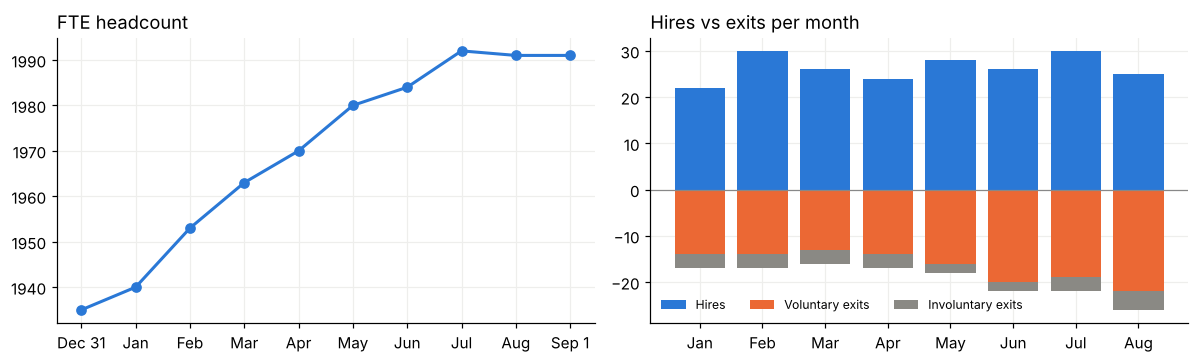

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(["Dec 31"] + [d.strftime("%b") for d in pts[1:-1]] + ["Sep 1"], q3.fte_headcount, color=BLUE, marker="o", lw=2); ax[0].set_title("FTE headcount", loc="left")
x = mv.index.strftime("%b")
ax[1].bar(x, mv.hires, color=BLUE, label="Hires"); ax[1].bar(x, -mv.voluntary_exits, color=ORANGE, label="Voluntary exits")
ax[1].bar(x, -mv.involuntary_exits, bottom=-mv.voluntary_exits, color=GRAY, label="Involuntary exits"); ax[1].axhline(0, color="#888", lw=.8)
ax[1].set_title("Hires vs exits per month", loc="left"); ax[1].legend(frameon=False, fontsize=8, ncol=3, loc="lower left")
plt.tight_layout(); plt.show()

In [26]:
dash_q3 = p.headcount_series(D, pts)
for d, nb, ds in zip(pts, q3.fte_headcount, dash_q3.headcount): check("Q3", f"FTE headcount {d:%Y-%m-%d}", int(nb), int(ds))
print("Q3 month-by-month vs dashboard:", "PASS" if all(c["match"]=="PASS" for c in CHECKS if c["question"]=="Q3") else "FAIL")

Q3 month-by-month vs dashboard: PASS


> **Answer Q3: yes, but growth is stalling.** FTE headcount rose from **1,935 to 1,991 (+56, +2.9%)**, against +74 over the same months of 2025. Hiring is steady at about 26 a month, but voluntary exits climbed from about 14 a month to 20–22 a month by summer. Net adds fell from about 9 a month in Jan–May (+45) to under 4 a month in Jun–Aug (+11), and August was negative. Commercial (Morgan's org) **shrank by 22**.

---
## Q4 · "Is voluntary attrition getting better or worse? By quarter, last two years."
**Approach:** for each calendar quarter, FTE voluntary exits ÷ average daily FTE headcount, annualized.
**Assumptions and limits:**
- The exit log starts on 8/15/2024, so the "last two years" is the 8 quarters Q4 2024 through Q3 2026. The Aug 15–Sep 30, 2024 stub is shown separately.
- Q3 2026 covers only Jul 1–Aug 31 (the data stops at the as-of date). It's annualized so it's comparable, and labeled partial.

In [27]:
quarters = [("2024 Q3 stub (from 8/15)", "2024-08-15", "2024-09-30")] + \
           [(f"{q.year} Q{q.quarter}", q.start_time, q.end_time.normalize()) for q in pd.period_range("2024Q4", "2026Q2", freq="Q")] + \
           [("2026 Q3 (Jul–Aug)", "2026-07-01", "2026-08-31")]
q4 = pd.DataFrame([dict(period=l, **attrition(fte, s, e)) for l, s, e in quarters])
q4_inv = pd.DataFrame([dict(period=l, **attrition(fte, s, e, ttype="Involuntary")) for l, s, e in quarters])
q4["involuntary_annualized"] = q4_inv.annualized
display(q4.style.format({"avg_hc": "{:,.1f}", "rate": "{:.2%}", "annualized": "{:.1%}", "involuntary_annualized": "{:.1%}"}))
ttm_prev = attrition(fte, "2024-09-01", "2025-08-31"); ttm_now = attrition(fte, "2025-09-01", "2026-08-31")
print(f"Trailing 12 months voluntary: {ttm_prev['annualized']:.1%} (Sep 24–Aug 25) -> {ttm_now['annualized']:.1%} (Sep 25–Aug 26); exits {ttm_prev['exits']} -> {ttm_now['exits']}")

,period,exits,avg_hc,rate,annualized,involuntary_annualized
0,2024 Q3 stub (from 8/15),12,"1,786.3",0.67%,5.2%,0.9%
1,2024 Q4,25,"1,806.3",1.38%,5.5%,2.2%
2,2025 Q1,35,"1,832.6",1.91%,7.7%,2.2%
3,2025 Q2,36,"1,857.6",1.94%,7.8%,1.9%
4,2025 Q3,36,"1,891.7",1.90%,7.6%,1.9%
5,2025 Q4,34,"1,913.9",1.78%,7.0%,1.9%
6,2026 Q1,41,"1,945.3",2.11%,8.5%,1.9%
7,2026 Q2,50,"1,974.4",2.53%,10.2%,1.4%
8,2026 Q3 (Jul–Aug),41,"1,990.5",2.06%,12.1%,2.1%


Trailing 12 months voluntary: 7.0% (Sep 24–Aug 25) -> 9.2% (Sep 25–Aug 26); exits 129 -> 180


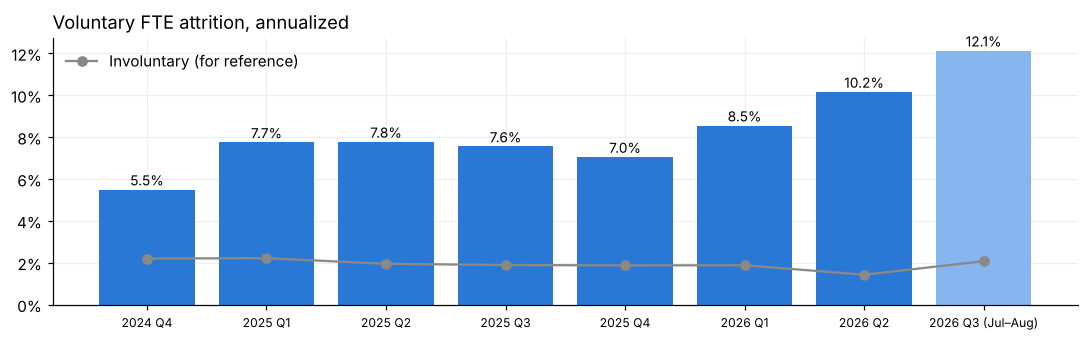

In [28]:
fig, ax = plt.subplots(figsize=(10, 3.2)); s = q4.iloc[1:]
bars = ax.bar(s.period, s.annualized, color=[BLUE]*7 + ["#86b6ef"])
for b, v in zip(bars, s.annualized): ax.text(b.get_x()+b.get_width()/2, v+.002, f"{v:.1%}", ha="center", fontsize=9)
ax.plot(s.period, s.involuntary_annualized, color=GRAY, marker="o", label="Involuntary (for reference)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax.set_title("Voluntary FTE attrition, annualized", loc="left"); ax.legend(frameon=False)
plt.xticks(fontsize=8); plt.tight_layout(); plt.show()

In [29]:
dq = p.attrition(D, p.quarters_back(AS_OF, 9, p.data_start(D)))
for (_, nb), (_, ds) in zip(q4.iterrows(), dq.iterrows()):
    check("Q4", f"{nb.period} exits", int(nb.exits), int(ds.exits)); check("Q4", f"{nb.period} annualized", round(nb.annualized, 10), round(ds.annualized_rate, 10), tol=1e-8)
check("Q4", "TTM voluntary rate (last 12 mo)", round(ttm_now["annualized"], 10), round(p.attrition(D, [("x", "2025-09-01", "2026-08-31")]).annualized_rate.iloc[0], 10), tol=1e-8)
print("Q4 vs dashboard:", "PASS" if all(c["match"]=="PASS" for c in CHECKS if c["question"]=="Q4") else "FAIL")

Q4 vs dashboard: PASS


> **Answer Q4: worse.** Annualized voluntary attrition went from **5.5% (Q4 2024)** to roughly **7–8% through 2025**, then **8.5% → 10.2% → 12.1%** across 2026. On a trailing-12-month basis it rose from **7.0% to 9.2%**. Involuntary attrition is flat at about 2%, so this is a resignation problem.

---
## Q5 · "Are first-year employees leaving at a higher rate? Getting worse? What should we do?"
**Approach:** split exits and headcount by tenure on each day (under 12 months vs 12+ months), so each group's rate uses **its own** headcount. Comparing first-year exits with *total* headcount would understate the problem.
**Two lenses:** (a) rates by quarter and trailing 12 months; (b) **hire cohorts**: what share of each quarter's hires left within 90 days and within 12 months.
**Interpretation check:** "early-career" could also mean *young*. I test age separately so the recommendation targets the right thing.

In [30]:
q5 = pd.DataFrame([dict(period=l, first_year=attrition(fte, s, e, tenure="lt1")["annualized"],
                        tenured=attrition(fte, s, e, tenure="ge1")["annualized"],
                        fy_exits=attrition(fte, s, e, tenure="lt1")["exits"]) for l, s, e in quarters[1:]])
q5["ratio"] = q5.first_year / q5.tenured
display(q5.style.format({"first_year": "{:.1%}", "tenured": "{:.1%}", "ratio": "{:.1f}x"}))
t = {(lab, ten): attrition(fte, s, e, tenure=ten) for lab, s, e in [("prior 12m", "2024-09-01", "2025-08-31"), ("last 12m", "2025-09-01", "2026-08-31")] for ten in ["lt1", "ge1"]}
pd.DataFrame(t).T.assign(annualized=lambda x: x.annualized.map("{:.1%}".format), avg_hc=lambda x: x.avg_hc.map("{:,.0f}".format))[["exits","avg_hc","annualized"]]

,period,first_year,tenured,fy_exits,ratio
0,2024 Q4,7.9%,4.7%,9,1.7x
1,2025 Q1,19.2%,4.7%,18,4.0x
2,2025 Q2,12.5%,6.8%,10,1.9x
3,2025 Q3,13.1%,6.6%,9,2.0x
4,2025 Q4,13.5%,6.0%,9,2.2x
5,2026 Q1,25.5%,5.8%,17,4.4x
6,2026 Q2,38.2%,5.7%,26,6.8x
7,2026 Q3 (Jul–Aug),39.8%,7.9%,18,5.1x


exits avg_hc annualized
prior 12m lt1   49.0    375      13.1%
          ge1   80.0  1,463       5.5%
last 12m  lt1   74.0    269      27.5%
          ge1  106.0  1,680       6.3%

In [31]:
coh = fte[fte.hire_date >= DATA_START].copy()
coh["cohort"] = coh.hire_date.dt.to_period("Q").astype(str)
ten = (coh.termination_date - coh.hire_date).dt.days
coh["vol_1yr"] = coh.termination_type.eq("Voluntary") & (ten < 365)
coh["left_90d"] = coh.termination_date.notna() & (ten < 90)
cohorts = coh.groupby("cohort").agg(hires=("stint_id","size"), resigned_within_12m=("vol_1yr","mean"), left_within_90d=("left_90d","mean"))
cohorts["12m_window_complete"] = [(pd.Period(q).end_time + pd.Timedelta(days=365)) <= AS_OF for q in cohorts.index]
display(cohorts.style.format({"resigned_within_12m": "{:.0%}", "left_within_90d": "{:.0%}"}))

,hires,resigned_within_12m,left_within_90d,12m_window_complete
cohort,,,,
2024Q3,36,8%,3%,True
2024Q4,63,13%,3%,True
2025Q1,67,13%,3%,True
2025Q2,82,17%,0%,True
2025Q3,70,26%,3%,False
2025Q4,74,15%,4%,False
2026Q1,78,14%,5%,False
2026Q2,78,15%,13%,False
2026Q3,55,4%,4%,False


In [32]:
S, E = pd.Timestamp("2025-09-01"), pd.Timestamp("2026-08-31")
emp["age"] = (AS_OF - emp.date_of_birth).dt.days / 365.25
fte = emp[emp.is_fte]
age = {b: attrition(fte[fte.age.between(lo, hi, inclusive="left")], S, E)["annualized"] for b, lo, hi in [("<30",0,30),("30-39",30,40),("40-49",40,50),("50+",50,200)]}
print("Voluntary attrition by AGE (last 12 mo):", {k: f"{v:.1%}" for k, v in age.items()}, " -> age is not the driver")

# Roll each person up to their VP and Director (works for leavers too: they sit under the right Director)
parent = hier.set_index("employee_id").manager_employee_id.to_dict()
def ancestor(e, lvl):
    while e is not None and not pd.isna(e):
        if level.get(e) == lvl: return f"{dname[e]} ({e})"
        e = parent.get(e)
    return "(none)"
emp["vp"] = emp.employee_id.map(lambda e: ancestor(e, "VP")); emp["director"] = emp.employee_id.map(lambda e: ancestor(e, "Director"))
emp["dept"] = emp.dept_code.map(raw["departments"].set_index("dept_code").dept_name)
fte = emp[emp.is_fte]
def by(dim):
    rows = []
    for k, g in fte.groupby(dim):
        a, b, c = attrition(g, S, E, tenure="lt1"), attrition(g, "2024-09-01", "2025-08-31", tenure="lt1"), attrition(g, S, E, tenure="ge1")
        rows.append({dim: k, "first-year exits": a["exits"], "avg first-year HC": round(a["avg_hc"], 1), "first-year rate": a["annualized"],
                     "prior 12m": b["annualized"], "12+ mo rate": c["annualized"]})
    return pd.DataFrame(rows).sort_values("first-year rate", ascending=False).style.format({c: "{:.1%}" for c in ["first-year rate","prior 12m","12+ mo rate"]})
display(by("vp")); display(by("director"))

Voluntary attrition by AGE (last 12 mo): {'<30': '9.4%', '30-39': '9.9%', '40-49': '8.8%', '50+': '9.0%'}  -> age is not the driver


,vp,first-year exits,avg first-year HC,first-year rate,prior 12m,12+ mo rate
3,Morgan Reyes (12866),30,54.600000,54.9%,16.8%,9.8%
2,Grace Okafor (13232),9,29.500000,30.5%,14.6%,5.0%
1,Dana Whitfield (10474),20,81.300000,24.6%,12.5%,5.0%
5,Sam Delgado (5352),11,58.700000,18.7%,12.8%,4.9%
6,Terrence Cole (7673),1,11.000000,9.1%,8.4%,8.6%
4,Priya Anand (9079),3,33.600000,8.9%,7.9%,5.3%
0,(none),0,0.000000,nan%,nan%,0.0%


,director,first-year exits,avg first-year HC,first-year rate,prior 12m,12+ mo rate
4,Elijah MacDonald (5603),10,14.600000,68.7%,10.2%,13.6%
18,Skylar Lee (14813),5,8.500000,59.0%,0.0%,1.7%
19,Yusuf Ruiz (10691),7,12.500000,56.1%,24.6%,9.1%
7,Genesis Clark (2319),8,16.200000,49.2%,19.4%,8.7%
12,Pierre OBrien (2845),5,11.400000,44.0%,13.6%,7.8%
13,Pierre Torres (5139),7,21.000000,33.3%,14.6%,5.3%
8,Kinsley Roberts (12343),12,43.600000,27.5%,11.1%,6.1%
10,Mila Wood (14609),1,4.100000,24.5%,0.0%,8.8%
5,Erik Ortiz (13039),2,8.500000,23.5%,14.4%,4.4%
1,Adeline Castillo (4393),6,28.700000,20.9%,15.5%,3.8%


In [33]:
fy = fte[fte.termination_type.eq("Voluntary") & ((fte.termination_date - fte.hire_date).dt.days < 365) & (fte.termination_date >= "2024-09-01")]
fy = fy.assign(period=np.where(fy.termination_date >= S, "last 12m", "prior 12m"))
display(pd.crosstab(fy.reason, fy.period)[["prior 12m", "last 12m"]])

period,prior 12m,last 12m
reason,,
Resignation - Career Growth,12,17
Resignation - Compensation,10,12
Resignation - Personal,12,8
Resignation - Relocation,7,22
Resignation - Return to School,8,15


In [34]:
for lab, s, e in [("prior 12m", "2024-09-01", "2025-08-31"), ("last 12m", "2025-09-01", "2026-08-31")]:
    for tn in ["lt1", "ge1"]:
        check("Q5", f"{lab} {tn} voluntary rate", round(attrition(fte, s, e, tenure=tn)["annualized"], 10),
              round(p.attrition(D, [(lab, s, e)], tenure=tn).annualized_rate.iloc[0], 10), tol=1e-8)
check("Q5", "Commercial first-year rate (last 12m)", round(attrition(fte[fte.employee_id.isin(m_org)], S, E, tenure="lt1")["annualized"], 10),
      round(p.attrition(D, [("x", S, E)], p.org_ids(D, morgan), tenure="lt1").annualized_rate.iloc[0], 10), tol=1e-8)
print("Q5 vs dashboard:", "PASS" if all(c["match"]=="PASS" for c in CHECKS if c["question"]=="Q5") else "FAIL")

Q5 vs dashboard: PASS


> **Answer Q5: yes, about 4x higher, and getting much worse.**
> - First-year voluntary attrition was **27.5%** over the last 12 months, vs **6.3%** for people with 12+ months. A year earlier it was 13.1% vs 5.5%. Since Q2 2026 it's been running at about **40%** annualized, while the tenured rate is roughly flat. **Almost all of the overall increase from Q4 comes from first-year employees.**
> - **It's tenure, not age:** voluntary attrition is about 9–10% in every age band.
> - **Concentration:** Commercial / Morgan Reyes' org runs at **55%** (Customer Service, Boise: 69%), but every VP's org has worsened (the rest of the company went from 12% to 21%).
> - **Very early exits:** 13% of Q2 2026 hires left within 90 days, against 0–5% for earlier cohorts.
>
> **Recommendations** (detailed in the write-up): (1) triage Commercial with stay interviews and leaver call-backs; (2) fix the first 90 days with realistic job previews, screening and 30/60/90 check-ins; (3) report first-year and 90-day attrition by Director monthly, with a goal of getting back to about 13%; (4) fix the hierarchy data so front-line manager effects become visible.

---
## Q6 · "Anything else we should know?"
Evidence for each item flagged in the write-up.

In [35]:
# (a) Commercial is shrinking while the rest grows
for name, ids in [("Commercial (Morgan)", m_org), ("Rest of company", set(emp.employee_id) - m_org)]:
    g = fte[fte.employee_id.isin(ids)]
    print(f"{name:22s} FTE {len(active(g, pd.Timestamp('2025-12-31'))):5d} -> {len(active(g, AS_OF)):5d}")
g = fte[fte.employee_id.isin(m_org)]
print("Commercial Aug 2026: resignations", ((g.termination_type=="Voluntary") & g.termination_date.between("2026-08-01","2026-08-31")).sum(),
      "| hires", g.hire_date.between("2026-08-01","2026-08-31").sum())

# (b) Pay compression: report earns more base than their manager
r = active(fte, AS_OF).assign(base=lambda x: x.employee_id.map(latest["Base"]))
r["mgr_base"] = r.manager_employee_id.map(r.set_index("employee_id").base)
comp_inv = r[r.base > r.mgr_base]
print(f"\nReports paid more than their own manager: {len(comp_inv)} (levels: {comp_inv.job_level.value_counts().to_dict()}, under {comp_inv.manager_employee_id.nunique()} managers)")

# (c) Scheduled pay changes
fut = comp[comp.effective_date > AS_OF].sort_values("effective_date")
prev = comp[comp.component=="Base"].sort_values("effective_date").groupby("employee_id").amount.shift()
print(f"\nPay changes after as-of: {len(fut)} on {fut.effective_date.dt.date.unique()}; median increase {(fut.amount / prev.loc[fut.index] - 1).median():.1%}")

Commercial (Morgan)    FTE   440 ->   418
Rest of company        FTE  1495 ->  1573
Commercial Aug 2026: resignations 14 | hires 5

Reports paid more than their own manager: 23 (levels: {'Senior Analyst': 23}, under 21 managers)

Pay changes after as-of: 40 on [datetime.date(2026, 10, 1)]; median increase 4.0%


**Also flagged** (evidence in Section 2): the hand-kept sheet's March 2026 error; leavers re-pointed to Directors, which hides manager-level attrition; the stale "Active" status for 8086; the duplicate identity; the Jan 5, 2015 hire-date spike; and implausible birth dates. All of these are also listed automatically in the dashboard's **Data health** tab, so they're re-checked on every upload.

---
## Validation summary: this notebook vs the dashboard
Every value below was computed twice: once by the plain-pandas logic in this notebook, and once by `pipeline.py`, the engine the dashboard runs on. The two use different algorithms for headcount and averaging, so a match is meaningful.

In [36]:
v = pd.DataFrame(CHECKS)
fmt = lambda x, m: (f"${x:,.2f}" if "USD" in m else f"{x:.4%}" if ("rate" in m or "annualized" in m) else f"{x:,.0f}")
v["notebook"] = [fmt(a, m) for a, m in zip(v.notebook, v.metric)]; v["dashboard"] = [fmt(a, m) for a, m in zip(v.dashboard, v.metric)]
print(f"{(v.match=='PASS').sum()} of {len(v)} checks PASS")
v

36 of 36 checks PASS


,question,metric,notebook,dashboard,match
0,Q1,Morgan Reyes org FTE headcount,418,418,PASS
1,Q2,Dana Whitfield org FTE TCC (USD),"$45,439,575.40","$45,439,575.40",PASS
2,Q3,FTE headcount 2025-12-31,"1,935","1,935",PASS
3,Q3,FTE headcount 2026-01-31,"1,940","1,940",PASS
4,Q3,FTE headcount 2026-02-28,"1,953","1,953",PASS
5,Q3,FTE headcount 2026-03-31,"1,963","1,963",PASS
6,Q3,FTE headcount 2026-04-30,"1,970","1,970",PASS
7,Q3,FTE headcount 2026-05-31,"1,980","1,980",PASS
8,Q3,FTE headcount 2026-06-30,"1,984","1,984",PASS
9,Q3,FTE headcount 2026-07-31,"1,992","1,992",PASS


In [37]:
assert (v.match == "PASS").all(), "Some checks failed: see table above"
print("All notebook answers match the dashboard engine.")

All notebook answers match the dashboard engine.
